## RFM (Recency, Frequency, Monetary) analysis is a customer segmentation technique. You can use it to identify high-value customers in a banking context based on:

**Recency: How recently a customer used banking services.**

**Frequency: How often they used services or made transactions.**

**Monetary: How much money they deposited, invested, or spent.**

In [1]:
#import libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
#READ THE FILE
bank = pd.read_csv("../data/bank_data_C.csv")

In [3]:
bank.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [4]:
#Statistics of the data
bank.describe(include='all')

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
count,1041614,1041614,1041614,1041614,1041614,1.041614e+06,1041614,1.041614e+06,1.041614e+06
unique,1041614,879358,17233,3,9275,NaN,55,NaN,NaN
top,T1,C5533885,1/1/1800,M,MUMBAI,NaN,7/8/16,NaN,NaN
freq,1,6,56292,760978,101997,NaN,27084,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,1.149986e+05,NaN,1.571221e+05,1.566096e+03
std,NaN,NaN,NaN,NaN,NaN,8.467609e+05,NaN,5.126352e+04,6.561464e+03
min,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,4.728140e+03,NaN,1.240410e+05,1.600000e+02
50%,NaN,NaN,NaN,NaN,NaN,1.676852e+04,NaN,1.642470e+05,4.575000e+02
75%,NaN,NaN,NaN,NaN,NaN,5.742885e+04,NaN,2.000220e+05,1.200000e+03


In [5]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041614 entries, 0 to 1041613
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1041614 non-null  object 
 1   CustomerID               1041614 non-null  object 
 2   CustomerDOB              1041614 non-null  object 
 3   CustGender               1041614 non-null  object 
 4   CustLocation             1041614 non-null  object 
 5   CustAccountBalance       1041614 non-null  float64
 6   TransactionDate          1041614 non-null  object 
 7   TransactionTime          1041614 non-null  int64  
 8   TransactionAmount (INR)  1041614 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 71.5+ MB


# Data cleaning and preprocessing

In [6]:
bank.isnull().sum()

TransactionID              0
CustomerID                 0
CustomerDOB                0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64

In [7]:
bank["CustomerDOB"] = bank["CustomerDOB"].str.replace("-", "/")
bank["CustomerDOB"] = pd.to_datetime(bank["CustomerDOB"], format="%d/%m/%y", errors='coerce')
bank["TransactionDate"] = pd.to_datetime(bank["TransactionDate"], format = '%d/%m/%y')

In [8]:
# create a new column (new age) for customer
def calculate_age(bank):
    bank["age"] = bank["TransactionDate"].dt.year - bank["CustomerDOB"].dt.year
    return bank

In [9]:
bank = calculate_age(bank)
bank.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22.0
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,-41.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,20.0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,43.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28.0


In [10]:
#correct the age of the customer which came out negative
bank[bank["age"] <=0 ]["CustomerDOB"]

1         2057-04-04
15        2068-07-10
29        2067-01-21
50        2066-07-25
78        2067-05-25
             ...    
1041542   2062-09-01
1041543   2067-05-07
1041547   2051-07-01
1041557   2048-07-15
1041583   2033-10-05
Name: CustomerDOB, Length: 54158, dtype: datetime64[ns]

In [11]:
#adjust the age
def adjust_year(bank):
    if bank.year > 2016:
        bank = bank.replace(year = bank.year - 100)
    return bank


In [12]:
bank["CustomerDOB"] = bank["CustomerDOB"].apply(adjust_year)

In [13]:
bank = calculate_age(bank)

In [14]:
bank.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22.0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,59.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,20.0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,43.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28.0


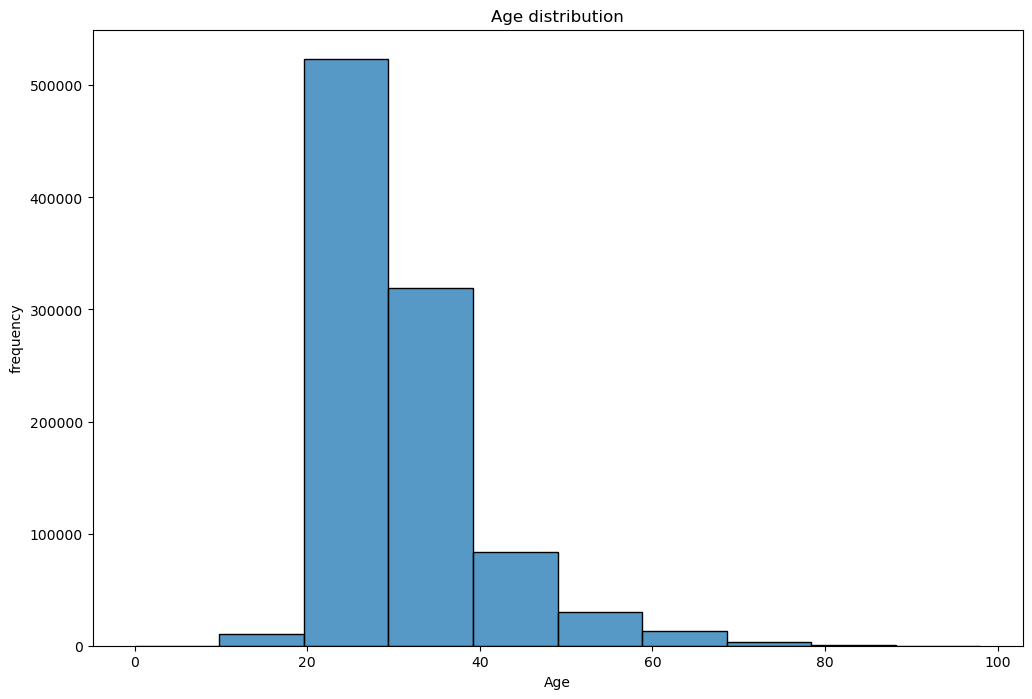

In [15]:
#further observation
plt.figure(figsize=(12,8))
sns.histplot(bank["age"], bins = 10, kde=False)
plt.xlabel("Age")
plt.ylabel("frequency")
plt.title("Age distribution")
plt.show()

In [16]:
bank[bank["age"] > 100]["CustomerDOB"].unique()

<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]

In [17]:
def replace_age_outlier(bank):
    DOB_threshold = 1900
    age_outliers = bank[bank["CustomerDOB"].dt.year < DOB_threshold].index

    mean_DOB = bank[~bank.index.isin(age_outliers)]["CustomerDOB"].mean()
    bank.loc[age_outliers, "CustomerDOB"] = mean_DOB
    return bank

In [18]:
bank = replace_age_outlier(bank)
bank = calculate_age(bank)

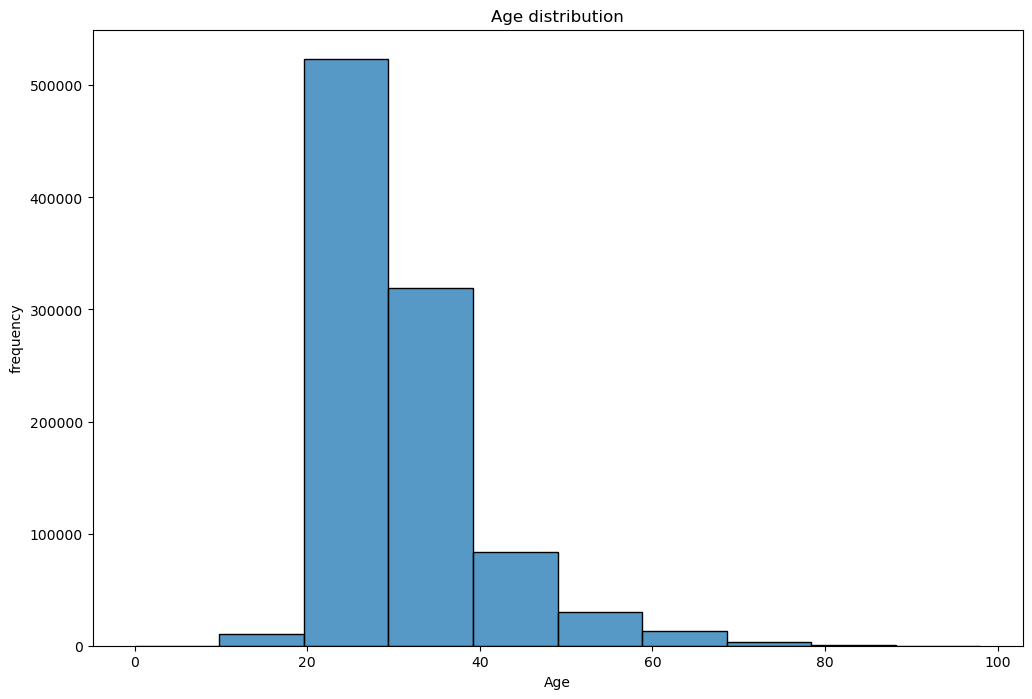

In [19]:
plt.figure(figsize=(12,8))
sns.histplot(bank["age"], bins = 10, kde=False)
plt.xlabel("Age")
plt.ylabel("frequency")
plt.title("Age distribution")
plt.show()

In [20]:
bank["CustGender"].value_counts()

CustGender
M    760978
F    280635
T         1
Name: count, dtype: int64

In [21]:
bank["CustGender"] =  bank["CustGender"].replace('T','M')

In [22]:
bank["CustGender"].value_counts()

CustGender
M    760979
F    280635
Name: count, dtype: int64

In [23]:
#Location
bank["CustLocation"].value_counts()

CustLocation
MUMBAI                            101997
NEW DELHI                          84143
BANGALORE                          81330
GURGAON                            73594
DELHI                              70549
                                   ...  
DISTRICT PURI                          1
DHAKOLA                                1
KANDESHWAR STATION NAVI MUMBAI         1
HOSHIAR PUR                            1
IMPERIA THANE WEST                     1
Name: count, Length: 9275, dtype: int64

In [24]:
#Account balance
bank["CustAccountBalance"].sort_values(ascending = True)

133809             0.0
1017262            0.0
665191             0.0
631012             0.0
242176             0.0
              ...     
995329     115035495.1
40727      115035495.1
994478     115035495.1
829903     115035495.1
873636     115035495.1
Name: CustAccountBalance, Length: 1041614, dtype: float64

In [25]:
bank[bank["TransactionAmount (INR)"] == 0].value_counts().sum()

708

In [26]:
bank.drop(bank[bank["TransactionAmount (INR)"] ==0].index.tolist(), axis = 0, inplace = True)

In [27]:
bank[bank["TransactionAmount (INR)"] == 0].value_counts().sum()

0

In [28]:
bank.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),age
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25.0,22.0
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,141858,27999.0,59.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,142712,459.0,20.0
3,T4,C5342380,1973-09-14,F,MUMBAI,866503.21,2016-08-02,142714,2060.0,43.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,181156,1762.5,28.0


## **EXPLORATORY DATA ANALYSIS (EDA)**

EDA is the foundation of effective data-driven decision-making, helping to uncover patterns, outliers, and relationships within your dataset. Whether it's customer behavior analysis, retention trends, or feature engineering, structured EDA ensures your models are based on well-understood data.

In [29]:
print(bank["CustomerID"].nunique())

878763


In [30]:
bank.shape

(1040794, 10)

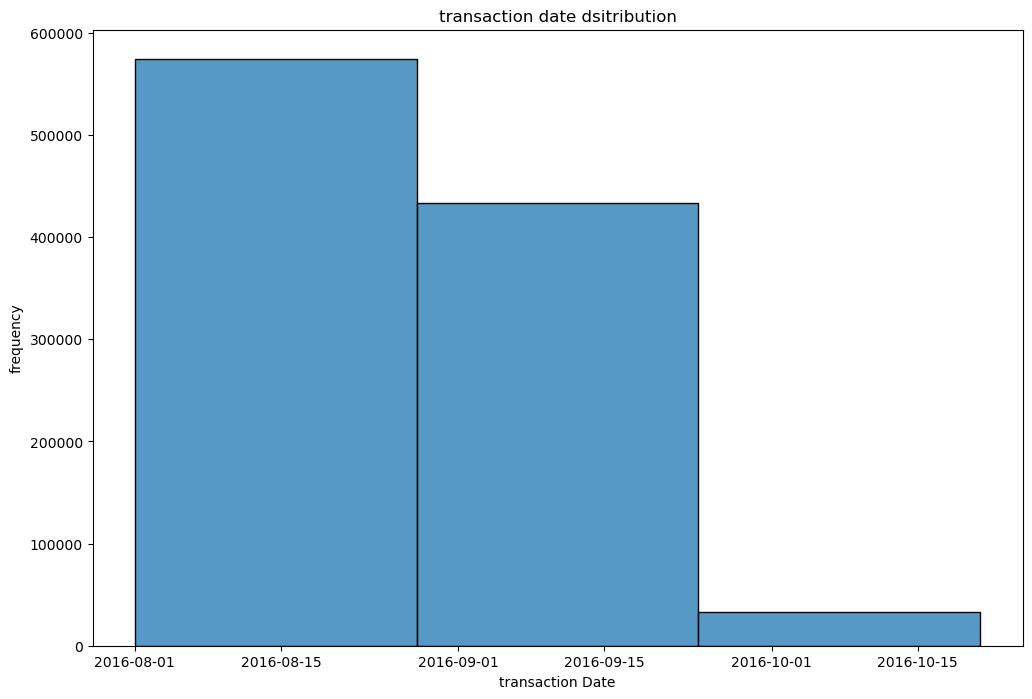

In [31]:
#plot a distribution for data across the unique transaction date
plt.figure(figsize = (12,8))
sns.histplot(bank["TransactionDate"], bins = 3, kde = False)
plt.xlabel("transaction Date")
plt.ylabel("frequency")
plt.title("transaction date dsitribution")
plt.show()

# EDA FOR AGE

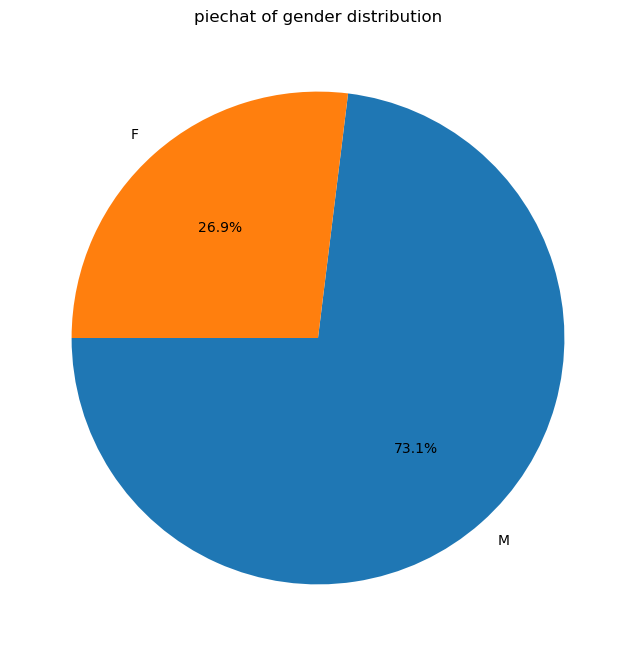

In [32]:
#create the Age percentage of customer

plt.figure(figsize= (8,8))
gender_percent= bank["CustGender"].value_counts()
plt.pie(gender_percent, labels= gender_percent.index, autopct='%1.1f%%', startangle = 180)
plt.title("piechat of gender distribution")
plt.show()

* The pie chart reveals a notable gender distribution, with 73.1% identified as "M" and 26.9% as "F." This disparity suggests that male participants significantly outnumber female participants in the dataset. Such insights can be valuable for understanding demographic trends, customer segmentation, and potential influences on behavior or engagement patterns.


## EDA OF AGE

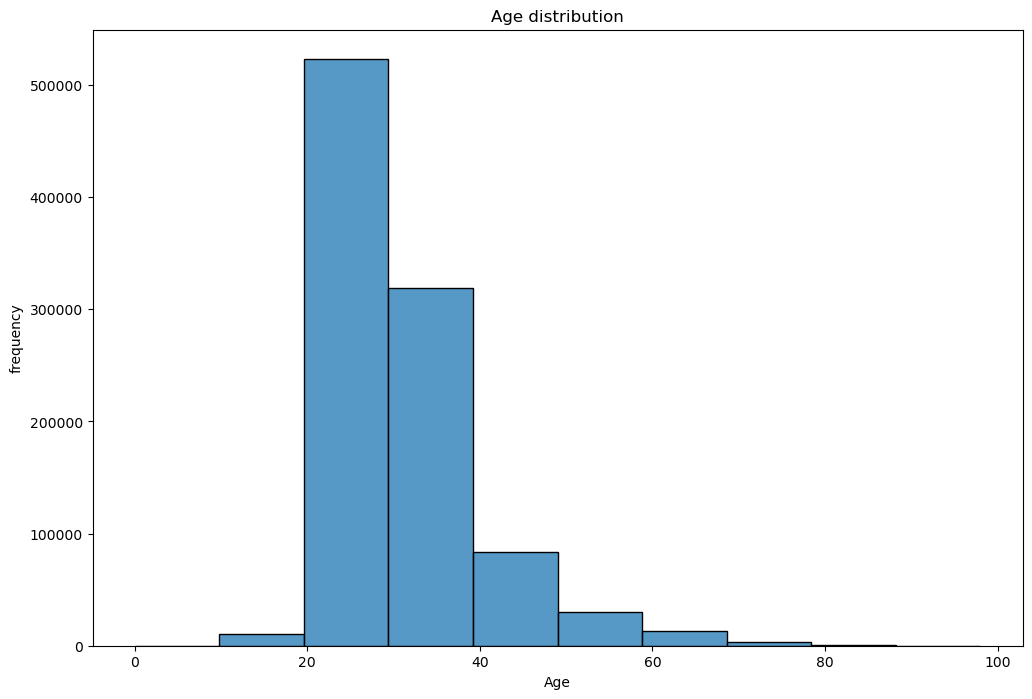

In [33]:
plt.figure(figsize=(12,8))
sns.histplot(bank["age"], bins = 10, kde=False)
plt.xlabel("Age")
plt.ylabel("frequency")
plt.title("Age distribution")
plt.show()


In [34]:
bank['AgeGroup'] = pd.cut(bank['age'], bins=[18, 30, 50, 80], labels=['Young', 'Middle', 'Senior'])
bank['AgeGroup'].value_counts()

AgeGroup
Young     583077
Middle    358449
Senior     38939
Name: count, dtype: int64

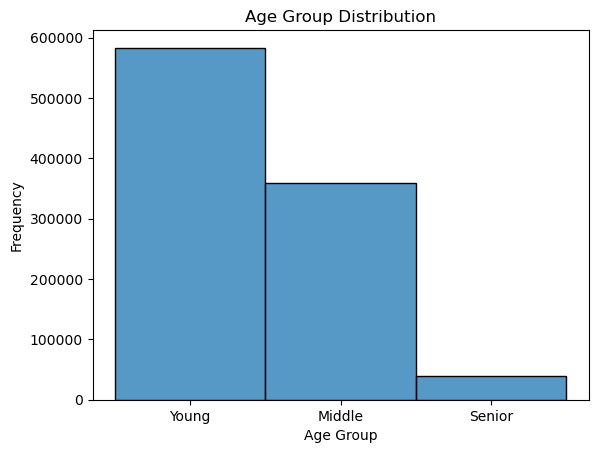

In [35]:

# Plot histogram of AgeGroup distribution
sns.histplot(bank['AgeGroup'], discrete=True)
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Frequency")
plt.show()

* The age group distribution reveals a strong concentration of younger individuals, with the Young category having the highest representation, followed by Middle, while Senior remains the smallest segment. This trend suggests that a majority of customers fall within younger demographics, which may influence consumer behavior, spending patterns, and retention strategies. Understanding how age impacts transaction activity could provide valuable insights for segmentation and targeted decision-making.


In [36]:
bank["CustLocation"].value_counts()

CustLocation
MUMBAI                 101918
NEW DELHI               84057
BANGALORE               81254
GURGAON                 73521
DELHI                   70470
                        ...  
COLONY JAMMU                1
KOLHAOUR                    1
WALCHANDNAGAR               1
RAJSAMAND RAJSAMAND         1
IMPERIA THANE WEST          1
Name: count, Length: 9271, dtype: int64

In [37]:
bank.groupby("CustLocation")["TransactionAmount (INR)"].mean().sort_values(ascending=False)

CustLocation
ROOMFORD             117621.000000
PALAKKARAI TRICHY    113291.546000
MUNCHEN              112592.857143
MILTON KEYNES        103579.000000
TEMPLE RAJAMUNDRY    100000.000000
                         ...      
RAOTA                     1.000000
ANANTAPUR DIST            1.000000
YEOLA DIST NASIK          1.000000
ULHASNAGAR 3              1.000000
NEGARA                    0.740000
Name: TransactionAmount (INR), Length: 9271, dtype: float64

In [38]:
daily_transactions = bank.groupby('TransactionDate')['TransactionAmount (INR)'].sum().reset_index()

In [39]:
daily_transactions.columns = ["TransactionDate", "TransactionAmount (INR)"]

In [40]:
daily_transactions.head()

,TransactionDate,TransactionAmount (INR)
0,2016-08-01,29328167.34
1,2016-08-02,30165998.15
2,2016-08-03,30655826.28
3,2016-08-04,35352319.56
4,2016-08-05,34431417.46


In [41]:
daily_transactions.rename({"TransactionAmount (INR)": "TransactionAmount"}, inplace=True)

In [42]:
daily_transactions.head()

,TransactionDate,TransactionAmount (INR)
0,2016-08-01,29328167.34
1,2016-08-02,30165998.15
2,2016-08-03,30655826.28
3,2016-08-04,35352319.56
4,2016-08-05,34431417.46


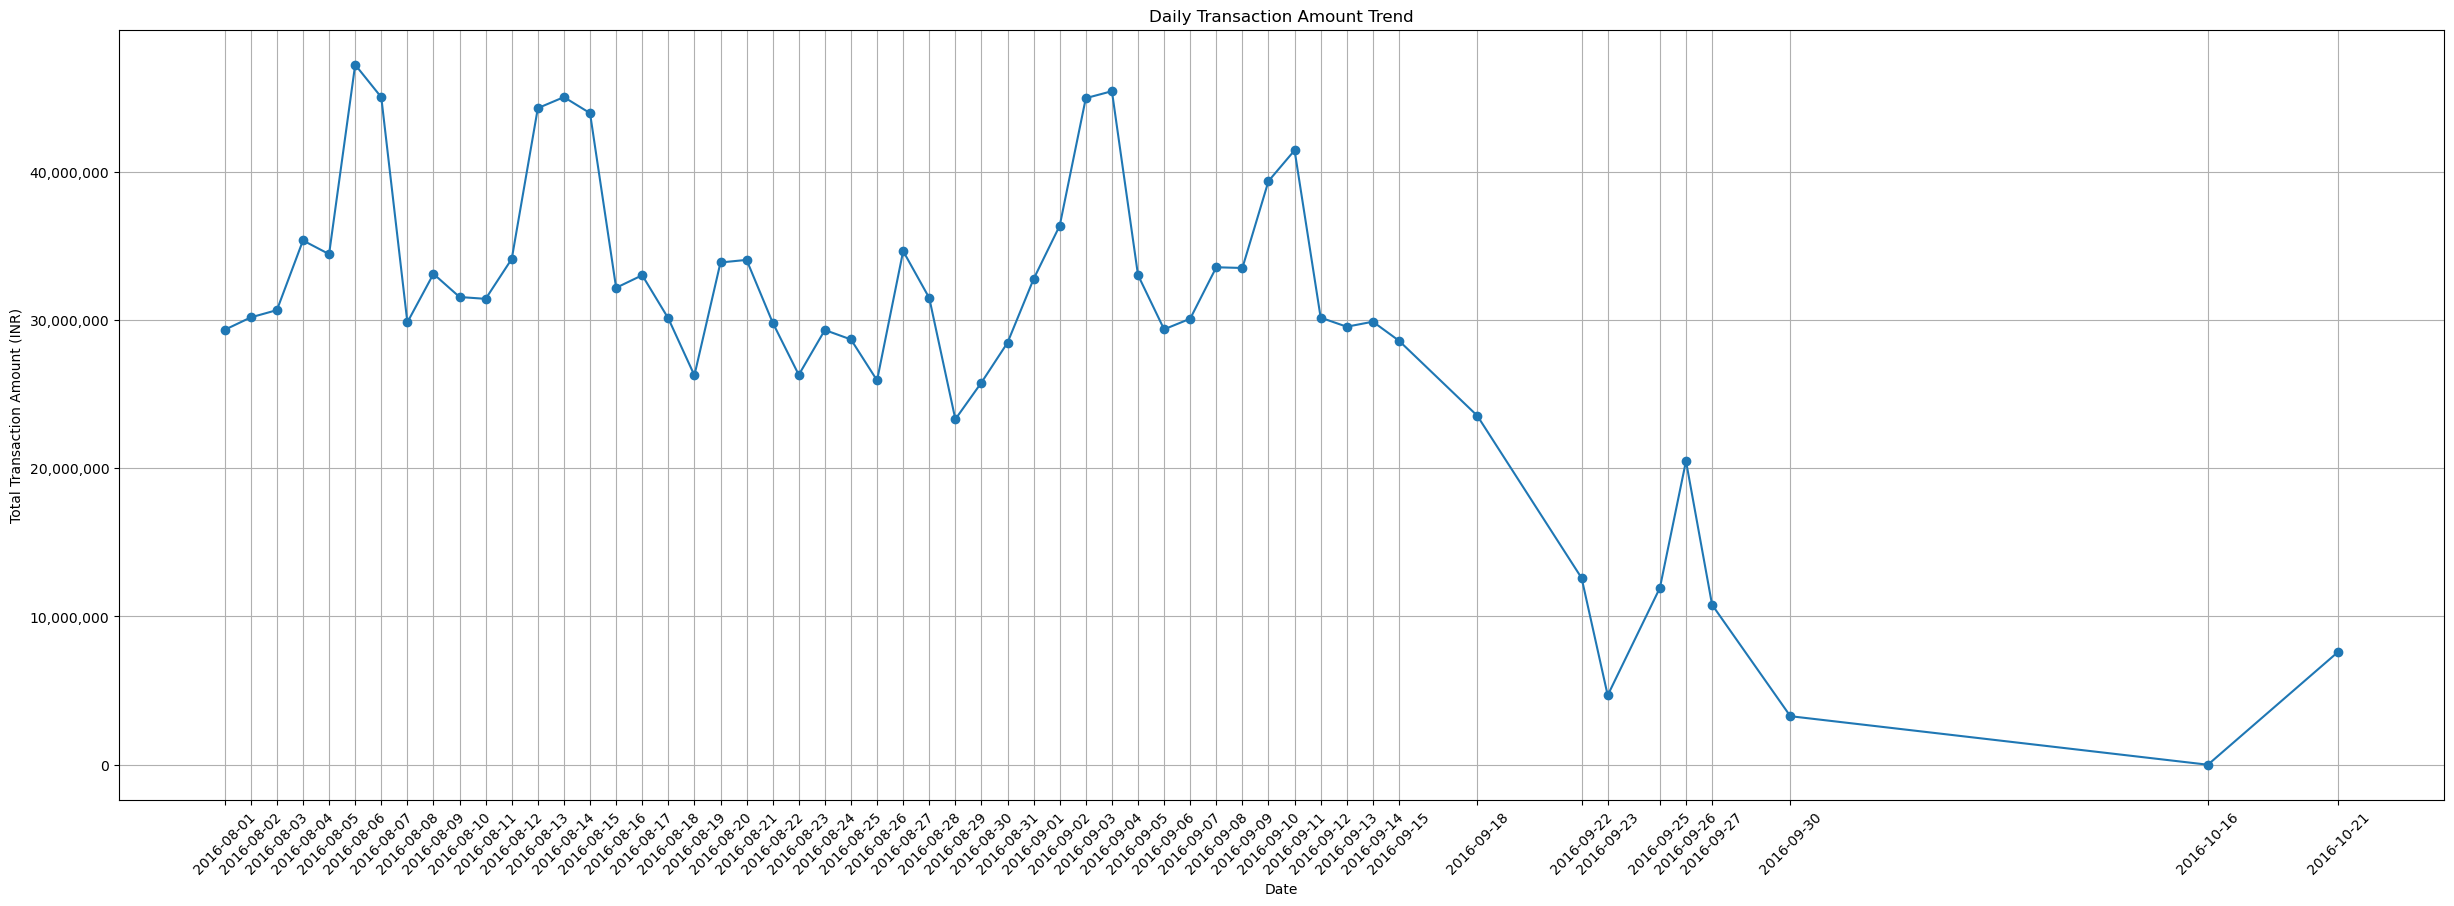

In [57]:
import matplotlib.ticker as ticker
plt.figure(figsize=(3
                    0, 10))
plt.plot(daily_transactions["TransactionDate"], daily_transactions["TransactionAmount (INR)"], marker='o', linestyle='-')

plt.xlabel('Date')
plt.ylabel('Total Transaction Amount (INR)')
plt.title('Daily Transaction Amount Trend')
plt.xticks(daily_transactions["TransactionDate"][::1], rotation=45)
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
plt.show()


This **Daily Transaction Amount Trend** graph provides a detailed view of transaction fluctuations over time, allowing for meaningful insights into spending behavior.

### **Key Observations:**
1. **Significant Peaks & Spending Surges**  
   - Major spikes occur around **August 5, August 15, and September 2**, where transaction amounts exceed **40,000,000 INR**.  
   - These peaks may correspond to **pay cycles, promotional events, or seasonal shopping trends**. Examining external factors can clarify whether these trends were expected.

2. **Steady Decline & Sudden Drop**  
   - After **September 23**, transaction amounts sharply decrease, reaching a low around **September 27**.  
   - This could indicate **reduced consumer activity, market shifts, or policy-related impacts** affecting transaction volume.

3. **Final Stabilization Toward the End**  
   - The slight increase on **September 21** suggests potential recovery or an isolated event driving transactions up again.  
   - Further analysis could reveal whether this trend is sustainable or merely a short-lived anomaly.
